### EAO - easy and straight forward optimization of energy setups

#### Import required packages

In [1]:
import math
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

import eaopack as eao

#### Load data & make assumptions
In this case we load a month of quarter-hourly data. We will use day ahead prices as well as PV production profiles.

In [2]:
data = pd.read_csv('bess_netherlands.csv', parse_dates=True)

######################### settings
battery_data = {} # capacity, size and efficiency of an on-site battery
battery_data['cap']  =  15.0 # 15 MW
battery_data['size'] = 2.0 * battery_data['cap'] # 2 hours
battery_data['eff']  = 0.909 # 90.9% round-trip efficiency

For the actual optimization we need to do some settings: Defining the time grid for optimization and defining which data to use in our assets.

In [3]:
######## prepare everything
## basics
S = pd.Timestamp(2026,6,1, tz='CET')
E = pd.Timestamp(2026,6,30, tz='CET')
timegrid = eao.Timegrid(S, E, freq = '15min', timezone='CET') # quarter-hourly

## settings
input_ts = pd.DataFrame()
input_ts['pv']    =  4*data['MWH'] # MW
input_ts['price'] =  data['Price'] # €/MWh

# cast to timegrid
input_ts = timegrid.prices_to_grid(input_ts)

Now we define the structure of our optimization problem -- our portfolio. The assets may be physical assets such as the battery or contracts such as supply via the grid.

In [4]:
### Structural setup
grid_connection = eao.Node('grid connection')

### Our own PV module. Also here without flexibility -- easily changed
pv          = eao.assets.RenewableAsset(name       = 'pv', 
                                        nodes      = grid_connection,
                                        profile    = input_ts['pv'].to_numpy())

### An on-site battery constituting out flexibility
battery     = eao.assets.Battery(       name       = 'battery',
                                        nodes      = grid_connection,
                                        cap_in     = battery_data['cap'],
                                        cap_out    = battery_data['cap'],                                        
                                        eff_in     = math.sqrt(battery_data['eff']),
                                        eff_out    = math.sqrt(battery_data['eff']),
                                        size       = battery_data['size'],
                                        max_cycles_no = 0.8,
                                        max_cycles_freq = 'd',
                                        start_level= 0.5 * battery_data['size'],
                                        end_level  = 0.5 * battery_data['size'],
                                        block_size = 'd',   # daily optimization of battery (leaving it 1/2 full every day)
                                        no_simult_in_out = True) # Important: The battery may now charge and discharge at the same time and
                                                                  # "burn" power due to efficiency < 100%. This makes computation much faster (no MIP)

### Supply/feed-in via the grid with different capacity constraints. Here we assume that the grid connection is limited to 5 MW consumption and 20 MW feed-in.
market_with_contraints  = eao.assets.SimpleContract(    name = 'contrained_market', 
                                        nodes       = grid_connection, 
                                        price       = 'price',
                                        min_cap     = -20, # feed-in at 20 MW
                                        max_cap     = 5) # supply at 5 MW

### Market without constraints. This is used for benchmarking the battery optimization.
market_without_constraints = eao.assets.SimpleContract(    name = 'unconstrained_market', 
                                        nodes       = grid_connection, 
                                        price       = 'price',
                                        min_cap     = -1000, # unlimited feed-in
                                        max_cap     = 1000)  # unlimited supply


# define the portfolio of all assets and contracts
portf = eao.Portfolio([market_with_contraints, pv, battery])

This is how the portfolio looks like (see below). We could set it up in a more complex way (distinction into in-front-of-the-meter and behind-the-meter) to incorporate grid fees. Here we start in the most simple way.

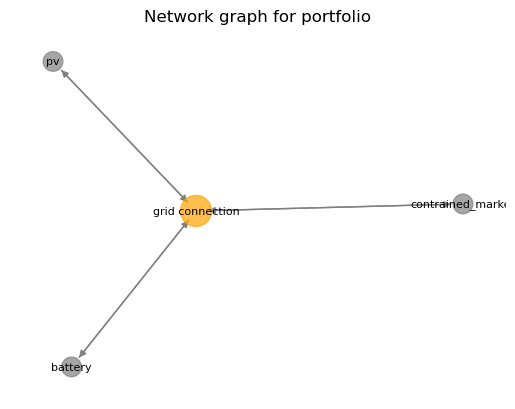

In [5]:
eao.network_graphs.create_graph(portf)

#### Optimization

The actual optimization is very simple. We collect all assets in the portfolio object and go. "extract_output" will generate straight-forward tables that can also be exported to Excel. Note that we are optimizing a full year on an hourly basis including a battery. This takes ~1 min.

In [6]:
out = eao.optimize(portf=portf, timegrid=timegrid, data=input_ts)
print(out['summary'])
eao.io.output_to_file(output=out, file_name='test.xlsx') ### All details. Have look into the file

                 Values
Parameter              
status       successful
value      364775.18899


Defining the benchmark to calculate the value of the battery: The same portfolio without the battery

In [7]:
portf_pv_benchmark = eao.portfolio.Portfolio([market_without_constraints, pv])
out_pv_benchmark   = eao.optimize(portf=portf_pv_benchmark, timegrid=timegrid, data=input_ts)

portf_battery_benchmark = eao.portfolio.Portfolio([market_without_constraints, battery])
out_battery_benchmark   = eao.optimize(portf=portf_battery_benchmark, timegrid=timegrid, data=input_ts)

#### Interpretation of the results

Let us compare the overall revenues of the pv with and without battery

In [20]:
print(f'Overall revenues pv with battery:\t\t{out["summary"].loc["value", "Values"]:,.0f}')
print(f'Overall revenues pv only:\t\t\t{out_pv_benchmark["summary"].loc["value", "Values"]:,.0f}')
print(f'Overall revenues battery only:\t\t\t{out_battery_benchmark["summary"].loc["value", "Values"]:,.0f}')
print(f'The battery increased the pv revenues by:\t{out["summary"].loc["value", "Values"] - out_pv_benchmark["summary"].loc["value", "Values"]:,.0f}')

Overall revenues pv with battery:		364,775
Overall revenues pv only:			238,015
Overall revenues battery only:			130,610
The battery increased the pv revenues by:	126,760
